## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS
| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | Ingreso mensual (`ingreso_mensual`), monto solicitado (`monto_solicitado`) y estado de morosidad (`tiene_historial_moroso`). |
| **Acciones (A)** | Aprobar solicitud, aprobar con condiciones o rechazar solicitud. |
| **Entorno (E)** | Sistema bancario, base de datos de clientes y solicitudes de crédito. |
| **Objetivo** | Maximizar la colocación de créditos rentables reduciendo el riesgo de desembolso a clientes morosos. |
| **Medida de Desempeño (P)** | Tasa de morosidad de créditos aprobados y volumen de créditos colocados con bajo riesgo. |

### Justificación de las reglas
Las reglas priorizan la salud financiera del banco al penalizar de inmediato a clientes con historial moroso directo cuando superan el límite base de financiamiento. Como tambien, una relación monto/ingreso menor a 0.3 garantiza la capacidad de pago del solicitante independientemente del historial, mientras que una carga financiera intermedia (0.3 a 0.5) requiere condiciones adicionales para mitigar el riesgo de incumplimiento.

### Implementación del Agente

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    if ingreso_mensual <= 0:
        return "rechazar", "Ingreso mensual inválido o cero"
    
    relacion = monto_solicitado / ingreso_mensual
    
    # Evaluación según reglas de negocio
    if tiene_historial_moroso and relacion > 0.5:
        return "rechazar", f"Relación monto/ingreso alta ({relacion:.2f}) con historial moroso"
    elif tiene_historial_moroso and relacion <= 0.5:
        return "aprobar con condiciones", f"Historial moroso presente pero relación endeudamiento baja ({relacion:.2f})"
    elif not tiene_historial_moroso and relacion <= 0.3:
        return "aprobar", f"Buen historial y excelente relación monto/ingreso ({relacion:.2f})"
    elif not tiene_historial_moroso and relacion <= 0.5:
        return "aprobar con condiciones", f"Sin historial moroso pero relación monto/ingreso moderada ({relacion:.2f})"
    else:
        return "rechazar", f"Relación monto/ingreso excesiva ({relacion:.2f}) sin importar el historial"

### Simulación y Pruebas

In [2]:
# Definición de al menos 6 casuísticas de prueba (incluyendo caso borde)
casos_prueba = [
    (5000, 1000, False),  # Relación 0.2 -> Aprobar
    (5000, 2000, False),  # Relación 0.4 -> Aprobar con condiciones
    (5000, 3000, False),  # Relación 0.6 -> Rechazar
    (4000, 1000, True),   # Relación 0.25 -> Aprobar con condiciones
    (4000, 2500, True),   # Relación 0.625 -> Rechazar
    (3000, 1500, False)   # Caso borde: Relación exacto 0.5 -> Aprobar con condiciones
]

print("--- EVALUACIÓN DE PRUEBAS ---")
for i, (ingreso, monto, moroso) in enumerate(casos_prueba, 1):
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Caso {i}: Ingreso={ingreso}, Monto={monto}, Moroso={moroso} | Acción: '{accion}' | Motivo: {motivo}")

--- EVALUACIÓN DE PRUEBAS ---
Caso 1: Ingreso=5000, Monto=1000, Moroso=False | Acción: 'aprobar' | Motivo: Buen historial y excelente relación monto/ingreso (0.20)
Caso 2: Ingreso=5000, Monto=2000, Moroso=False | Acción: 'aprobar con condiciones' | Motivo: Sin historial moroso pero relación monto/ingreso moderada (0.40)
Caso 3: Ingreso=5000, Monto=3000, Moroso=False | Acción: 'rechazar' | Motivo: Relación monto/ingreso excesiva (0.60) sin importar el historial
Caso 4: Ingreso=4000, Monto=1000, Moroso=True | Acción: 'aprobar con condiciones' | Motivo: Historial moroso presente pero relación endeudamiento baja (0.25)
Caso 5: Ingreso=4000, Monto=2500, Moroso=True | Acción: 'rechazar' | Motivo: Relación monto/ingreso alta (0.62) con historial moroso
Caso 6: Ingreso=3000, Monto=1500, Moroso=False | Acción: 'aprobar con condiciones' | Motivo: Sin historial moroso pero relación monto/ingreso moderada (0.50)


### Visualización

### Generación de Datos y Scatter Plot

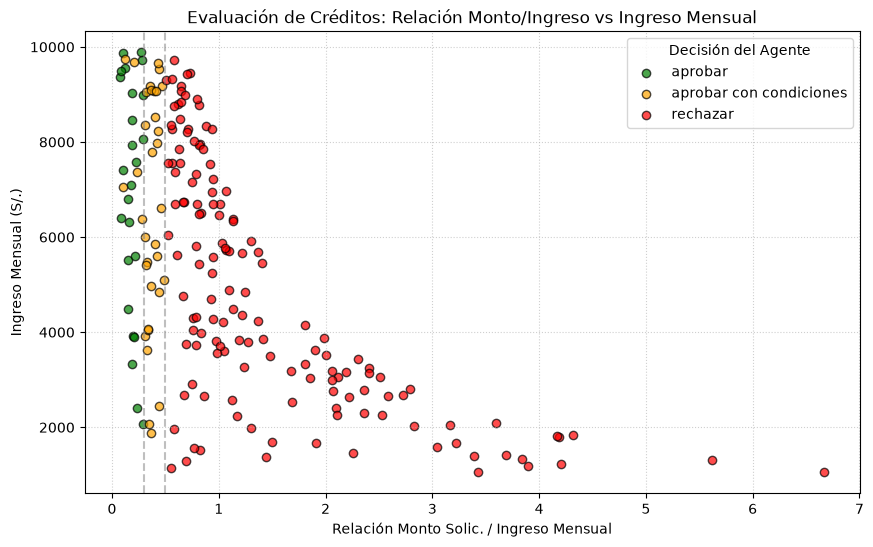

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # Semilla para reproducibilidad

# Generar 200 solicitudes aleatorias
n_muestras = 200
ingresos = np.random.uniform(1000, 10000, n_muestras)
montos = np.random.uniform(500, 8000, n_muestras)
historiales = np.random.choice([True, False], size=n_muestras, p=[0.3, 0.7])

acciones = []
relaciones = []

for ing, mon, mor in zip(ingresos, montos, historiales):
    accion, _ = agente_credito(ing, mon, mor)
    acciones.append(accion)
    relaciones.append(mon / ing)

# Mapeo de colores y estilos
color_map = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

plt.figure(figsize=(10, 6))

for accion, color in color_map.items():
    idx = [i for i, a in enumerate(acciones) if a == accion]
    plt.scatter(
        np.array(relaciones)[idx], 
        np.array(ingresos)[idx], 
        c=color, 
        label=accion, 
        alpha=0.7, 
        edgecolors='k'
    )

plt.title("Evaluación de Créditos: Relación Monto/Ingreso vs Ingreso Mensual")
plt.xlabel("Relación Monto Solic. / Ingreso Mensual")
plt.ylabel("Ingreso Mensual (S/.)")
plt.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.legend(title="Decisión del Agente")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()